# Social Media Sanctions and Misinformation Sharing: Solution

Our first job is to include anything we will need to solve this exersize. Keep in mind you will need to have the packages installed either in a virtual enviroment (recomended) or in your global python installation. To do this you can use pip:\
```pip install pandas scipy numpy matplotlib seaborn```

In [80]:
import math
import statistics

import pandas as pd
import numpy as np

import scipy.stats as stats # type: ignore
from scipy.stats import ttest_ind, pearsonr, mstats
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Twitter Suspensions after the 2020 Election

First we will load our data

In [39]:
file_path = 'mosleh_et_al_data.csv'
data = pd.read_csv(file_path)

Now we shall crosstabulate! After reading the paper and the data we know that a 1 in the `suspended` column means the account was subsequently suspended and that a 1 in the `politics_hashtag` column shows that they shared `#Trump2020` during the election

In [ ]:
# normalize='index' normalizes our index (just making sure that's clear)
contingency_table = pd.crosstab(data['politics_hashtag'], data['suspended'], margins=False, normalize='index')

print("Contingency Table (Row Percentages):")
print(contingency_table)

# Calculate the factor
print(f"\nTrump to No-Trump suspension factor: {contingency_table[1][1]/contingency_table[1][0]:.2f}")


Contingency Table (Row Percentages):
suspended                0         1
politics_hashtag                    
0                 0.955506  0.044494
1                 0.804218  0.195782

Trump to No-Trump suspension factor: 4.40


Now we must perform a $\chi^2$ test. Our raw contingency table is not normalized as this would add an unnecessary $\lambda$ factor to our $\chi^2$ which we don't want [cite]

In [41]:
# Create the raw contingency table for chi-squared
raw_contingency = pd.crosstab(data['politics_hashtag'], data['suspended'])
# Perform the chi-squared test
chi2, p, dof, expected = stats.chi2_contingency(raw_contingency)
# Display chi-squared results
print("\nChi-squared Test Results:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")


Chi-squared Test Results:
Chi2 Statistic: 485.4671
P-value: 0.0000


This shows us with (almost) absolute certainty that there is a statistically significant correlation between the subsequent suspension of an account and the posting of `#Trump2020` by that same account earlier. To be exact the chance is about 4.4 times more than if not posting `#Trump2020`.

## Distributions of Relative Frequency of Low Quality

Now we must create the two plots (we name them 1a and 1b). First thing we do is standardize our x axis with z values*


_$$*z = \frac{x - \mu}{\sigma}$$_


In [42]:
data[f'z_lowqual_pr2019_fc'] = (data["lowqual_pr2019_fc"] - data["lowqual_pr2019_fc"].mean()) / data["lowqual_pr2019_fc"].std()
data[f'z_lowqual_pr2019_crowd'] = (data["lowqual_pr2019_crowd"] - data["lowqual_pr2019_crowd"].mean()) / data["lowqual_pr2019_crowd"].std()

Now we must once again crosstabulate the data

In [43]:
# Fig 1A: Tabulate 'z_lowqual_pr2019_fc' by 'politics_hashtag'
contingency_1a = pd.crosstab(data['z_lowqual_pr2019_fc'], data['politics_hashtag'], normalize='columns')

We continue on to our visualization.\
_To make them looks exactly the same I followed what is stipulated in the appendix_

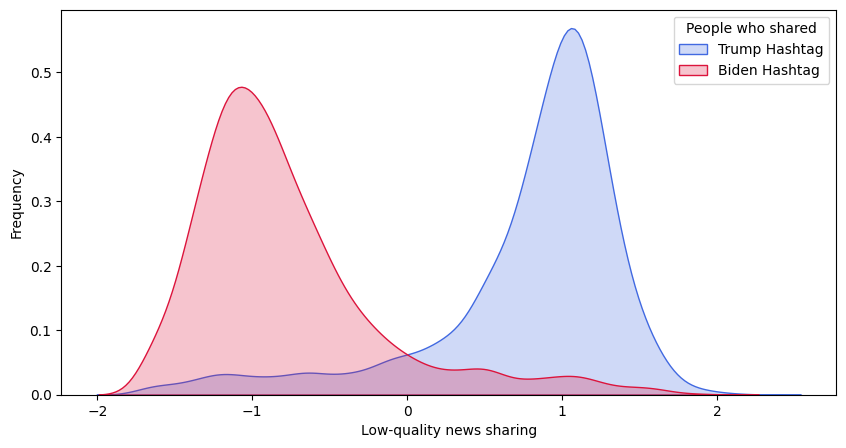

In [44]:
plt.figure(figsize=(10, 5))

# Use hue parameter to differentiate between Trump and Biden hashtags
sns.kdeplot(
    data=data,
    x='z_lowqual_pr2019_fc', 
    hue='politics_hashtag',
    fill=True,
    palette={0: '#dc143c', 1: '#4169e1'},
    alpha=0.25,
    legend=True
)

plt.xlabel('Low-quality news sharing')
plt.ylabel('Frequency')
plt.legend(title='People who shared', labels=['Trump Hashtag','Biden Hashtag'])
plt.show()

We do exactly the same steps for our second figure

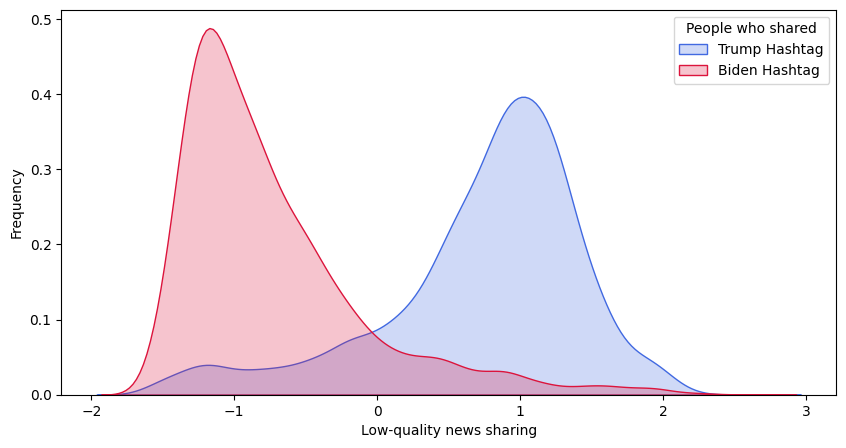

In [45]:
# Fig 1B: Tabulate 'z_lowqual_pr2019_crowd' by 'politics_hashtag'
contingency_1b = pd.crosstab(data['z_lowqual_pr2019_crowd'], data['politics_hashtag'], normalize='columns')
plt.figure(figsize=(10, 5))

# Use hue parameter to differentiate between Trump and Biden hashtags
sns.kdeplot(
    data=data,
    x='z_lowqual_pr2019_crowd', 
    hue='politics_hashtag',
    fill=True,
    palette={0: '#dc143c', 1: '#4169e1'},
    alpha=0.25,
    legend=True
)

plt.xlabel('Low-quality news sharing')
plt.ylabel('Frequency')
plt.legend(title='People who shared', labels=['Trump Hashtag','Biden Hashtag'])
plt.show()


## Low-quality News Sharing on Twitter

To examine on a quatitative manner, using a t-test, weaither `politics_hashtag` has an effect we must first set some metrics. We will add these to functions and then use them in the end to conduct our test

In [46]:
def pooled_standard_deviation(s1, s2):
    """
    Calculate the pooled standard deviation for two samples.
    
    """
    # Calculate sample standard deviations
    sd_1 = statistics.stdev(s1)
    sd_2 = statistics.stdev(s2)
    
    # Calculate sample lengths
    n1 = len(s1)
    n2 = len(s2)
    
    # Compute pooled standard deviation
    pooled_std = math.sqrt(
        ((n1 - 1) * sd_1 ** 2 + 
         (n2 - 1) * sd_2 ** 2) / 
        (n1 + n2 - 2)
    )
    
    return pooled_std

To quatify the effect size we will use Cohen's $d$ and and Hedges' $g$.

For Cohen's $d$ we use the pooled standrad deviation fuction we created above in order to calculate: $$ d = \frac{\bar{x}_{1} - \bar{x}_{2}}{s} $$

In [47]:
def cohens_d(s1, s2):
    """
    Calculate Cohen's d
    """
    # Calculate means of both groups
    mean1 = np.mean(s1)
    mean2 = np.mean(s2)
    
    # Calculate pooled standard deviation
    pooled_std = pooled_standard_deviation(s1, s2)
    
    # Calculate Cohen's d
    cohens_d = (mean1 - mean2) / pooled_std
    
    return cohens_d


And  for Hedges' $g$ we use the Cohen's $d$ we just created in order to find: $$ \Bigg(1 - \frac{3}{4  (n_1 + n_2) - 9)}\Bigg)d $$

In [48]:
def hedges_g(s1, s2):
    """
    Calculate Hedges' g
    """
    # Calculate sample lengths
    n1 = len(s1)
    n2 = len(s2)
    
    # Calculate correction factor
    correction_factor = 1 - (3 / (4 * (n1 + n2) - 9))
    
    # Calculate Hedges' g
    hedges_g = correction_factor * cohens_d(s1, s2)
    
    return hedges_g

Before continuing with our t-tests it's important to note that we assume that the populations **do not** have equal variances. It's currently the preferred approach to _not_ perform an ANOVA test before our t-test to gauge weather or not our populations are of equal variance. This is because type one errors might be inflated. Please see [here](https://doi.org/10.1348/000711004849222) and [here](https://doi.org/10.1214/09-STS301) for more information.

In [49]:
# Variables for quality metrics
metrics = [
    'lowqual_pr2019_fc', 'lowqual_afm', 'lowqual_mbfc', 
    'lowqual_lasser2019', 'lowqual_pr2019_crowd', 'lowqual_pr2019_crowdrep'
]

# Grouping variable
grouping_variable = 'politics_hashtag'

# Loop through each metric
results = []
for metric in metrics:
    # Split data into two groups based on `politics_hashtag`
    trump_group = data[data[grouping_variable] == 1][metric].dropna()
    biden_group = data[data[grouping_variable] == 0][metric].dropna()
    
    # Welch's T-test as we assume non equal variances
    t_stat, p_value = ttest_ind(trump_group, biden_group, equal_var=False) 
    
    # Calculate Cohen's d
    effect_size_d = cohens_d(trump_group, biden_group)

    # Calculate hedges's g
    effect_size_g = hedges_g(trump_group, biden_group)
    
    # Store results
    results.append({
        'Metric': metric,
        'Trump_Mean': trump_group.mean(),
        'Biden_Mean': biden_group.mean(),
        'T-Statistic': t_stat,
        'P-Value': f"{p_value:.12f}",
        'Effect_Size (Cohen\'s d)': effect_size_d,
        'Effect_Size (Hedges\'s g)': effect_size_g
    })

# Convert results to DataFrame for display
results_df = pd.DataFrame(results)

# Display results
print(results_df)


                    Metric  Trump_Mean  Biden_Mean  T-Statistic  \
0        lowqual_pr2019_fc    0.653052    0.278144   119.246476   
1              lowqual_afm    0.360563    0.190184   102.711200   
2             lowqual_mbfc    0.498072    0.328687    97.584148   
3       lowqual_lasser2019    0.641664    0.346232   102.679384   
4     lowqual_pr2019_crowd    0.690696    0.584678   102.501955   
5  lowqual_pr2019_crowdrep    0.720120    0.684697    61.083019   

          P-Value  Effect_Size (Cohen's d)  Effect_Size (Hedges's g)  
0  0.000000000000                 2.521188                  2.520977  
1  0.000000000000                 2.164878                  2.164698  
2  0.000000000000                 2.057540                  2.057369  
3  0.000000000000                 2.163831                  2.163650  
4  0.000000000000                 2.166782                  2.166601  
5  0.000000000000                 1.291464                  1.291356  


We notice that for every single metric Trump's Mean is higher than Biden's Mean while this difference is statistically significant to the greatest degree. Both effect size metrics (Cohen's d and Hedges's g) show a Huge effect for all metrics except for sites rated by the republicans. Even then though the effect size is Very Large. Pretty conclusive I would say! 

### Sharing Lower-quality News Sources and Conservative Ideology

We are performing pairwise between:

| Low Quality Indicators | Political Ideology Indicators |
|------------------------|-------------------------------|
| `lowqual_pr2019_fc` | `politics_followed` |
| `lowqual_lasser2019` | `politics_hashtag` |
| `lowqual_mbfc` | `politics_sites1` |
| `lowqual_afm` | `politics_sites2` |
| `lowqual_pr2019_crowd` | |
| `lowqual_pr2019_crowdrep` | |

We will then create a heatmap with the results

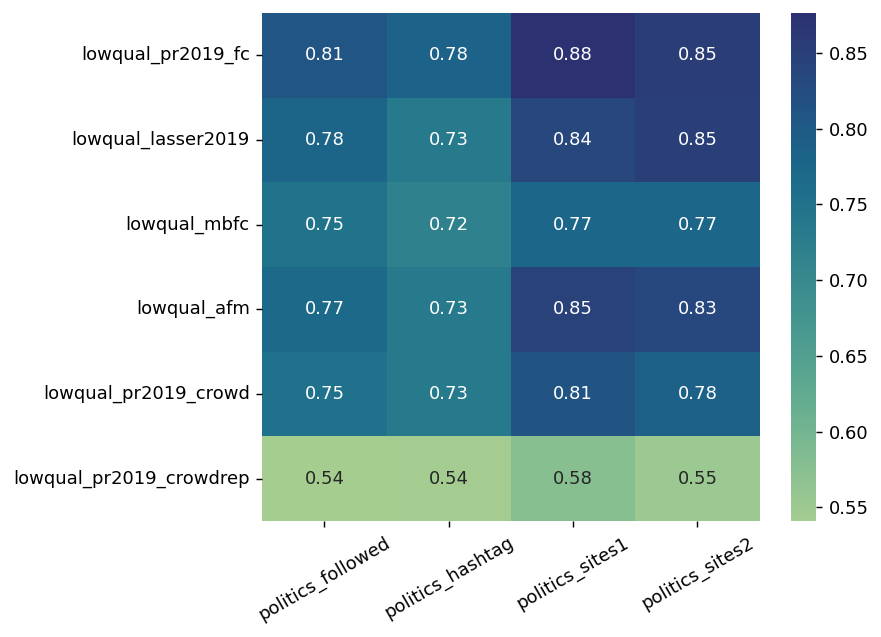

In [50]:
# Define the two sets of variables
loquals = [
    'lowqual_pr2019_fc', 'lowqual_lasser2019', 'lowqual_mbfc',
    'lowqual_afm', 'lowqual_pr2019_crowd', 'lowqual_pr2019_crowdrep'
]
politics = [
    'politics_followed', 'politics_hashtag', 'politics_sites1', 'politics_sites2'
]

# Create a DataFrame to store the correlations
heatmap_data = pd.DataFrame(index=loquals, columns=politics)

# Calculate correlations for the heatmap
for loqual_ind in loquals:
    for politic in politics:
        df_pair = data[[loqual_ind, politic]].dropna()
        # Calculate Pearson correlation
        correlation_p, _ = pearsonr(df_pair[loqual_ind], df_pair[politic])
        heatmap_data.loc[loqual_ind, politic] = correlation_p


heatmap_data = heatmap_data.astype(float)

 # A 4:3 aspect ratio was used in the figure of our text
plt.figure(figsize=(7, 5), dpi=130)

# Create the heatmap using Seaborn
sns.heatmap(
    heatmap_data, 

    # We made the heatmap with the correct values but we will display rounded 
    annot=heatmap_data.round(2),

    # Analyzing the svg (see appendix) yielded color codes that matched crest
    cmap=sns.color_palette(palette='crest', as_cmap=True),

    fmt=".2f", 
    cbar_kws={
        'format': '%.2f',
        'pad': 0.05 # This brings the bar closer
    }
)

# Rotate the x-axis labels
plt.xticks(rotation=30, ha='center', va='top')

plt.tight_layout()
plt.show()


## News Sharing Can Help Explain Suspension, Using Single Predictors

Now let us predict using a single variable weather or not a user was suspended. We use probit as requested. Our y is whether they were subsequently suspended and our X is each of our predictors: politics_hashtag, politics_sites1, politics_sites2, politics_followed, lowqual_afm, lowqual_mbfc, lowqual_lasser2019, lowqual_pr2019_fc and lowqual_pr2019_crowd. To evaluate we use the AUC of the ROC curve. 

First we will create a function that performs bootstrapping 100 times in order to get the confidence intervals. We will use the 2.5% confidence intervals

In [51]:
def bootstrap_auc(df, y_column, X_columns):
    """
    Perform bootstrap resampling 100 times
    
    """
    aucs = []
    for _ in range(100):
        df_bootstrap = df.sample(n=len(df), replace=True, random_state=69)
        
        y = df_bootstrap[y_column]
        X = sm.add_constant(df_bootstrap[X_columns])
        
        probit_model = sm.Probit(y, X).fit(disp=0)
        y_pred = probit_model.predict(X)
        
        aucs.append(roc_auc_score(y, y_pred))
    
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)


Now we will cycle through our predictors and perform our AUC calculations.

In [52]:
# Predictors to loop through
predictors = [
    'politics_hashtag',
    'politics_sites1',
    'politics_sites2',
    'politics_followed',
    'lowqual_afm',
    'lowqual_mbfc',
    'lowqual_lasser2019',
    'lowqual_pr2019_fc',
    'lowqual_pr2019_crowd'
]

results = {
    'Variable': [],
    'AUC': [],
    'CI Lower': [],
    'CI Upper': []
}

for predictor in predictors:
    df_single_probit = data[['suspended', predictor]].dropna()
    y = df_single_probit['suspended']
    X = sm.add_constant(df_single_probit[predictor])
    
    probit_model = sm.Probit(y, X).fit(disp=0) # make it be quiet
    
    y_pred = probit_model.predict(X)
    
    # Calculate AUC of the ROC
    auc = roc_auc_score(y, y_pred) 
    
    # Bootstrap confidence intervals
    ci_lower, ci_upper = bootstrap_auc(df_single_probit, 'suspended', predictor)
    
    # Append results to the dictionary
    results['Variable'].append(predictor)
    results['AUC'].append(auc)
    results['CI Lower'].append(ci_lower)
    results['CI Upper'].append(ci_upper)
    
    print(f"Variable: {predictor},  AUC: {auc:.3f},  CI: ({ci_lower:.3f}, {ci_upper:.3f})")

# Convert results to a DataFrame 
results_df = pd.DataFrame(results)


Variable: politics_hashtag,  AUC: 0.679,  CI: (0.676, 0.676)
Variable: politics_sites1,  AUC: 0.701,  CI: (0.699, 0.699)
Variable: politics_sites2,  AUC: 0.705,  CI: (0.697, 0.697)
Variable: politics_followed,  AUC: 0.716,  CI: (0.698, 0.698)
Variable: lowqual_afm,  AUC: 0.716,  CI: (0.711, 0.711)
Variable: lowqual_mbfc,  AUC: 0.706,  CI: (0.706, 0.706)
Variable: lowqual_lasser2019,  AUC: 0.706,  CI: (0.701, 0.701)
Variable: lowqual_pr2019_fc,  AUC: 0.698,  CI: (0.700, 0.700)
Variable: lowqual_pr2019_crowd,  AUC: 0.686,  CI: (0.691, 0.691)


Finnaly let us plot our results

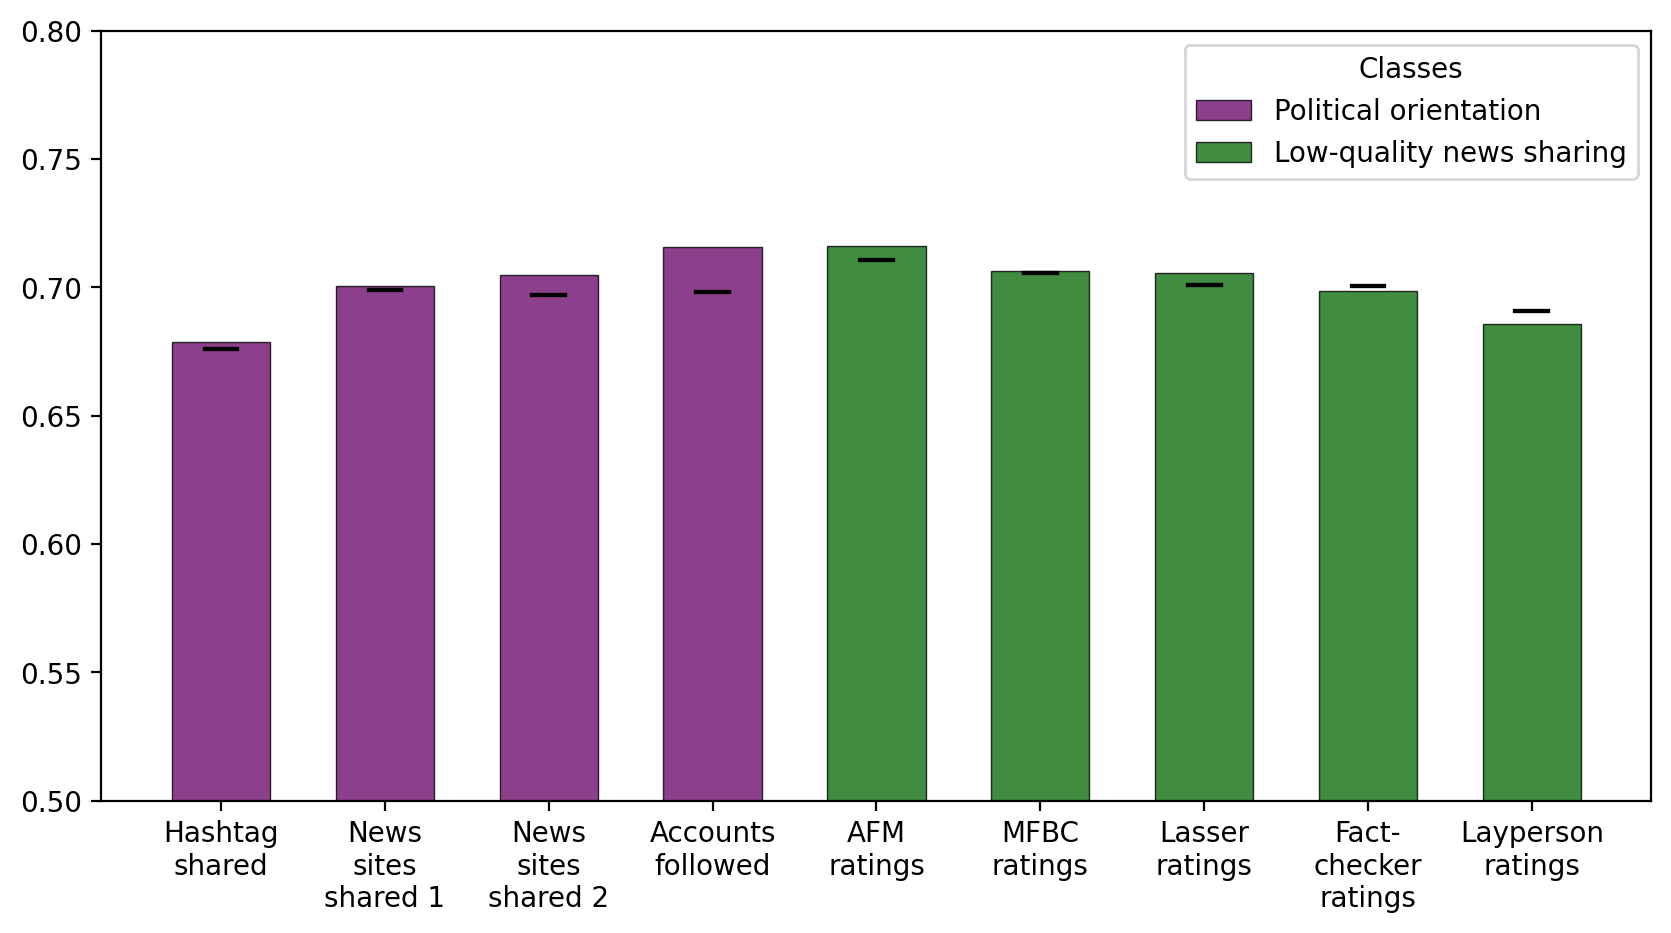

In [53]:
# Dictionary to map variables to more readable names
bar_plot_names = {
    'politics_hashtag': 'Hashtag\nshared',
    'politics_sites1': 'News\nsites\nshared 1',
    'politics_sites2': 'News\nsites\nshared 2',
    'politics_followed': 'Accounts\nfollowed',
    'lowqual_afm': 'AFM\nratings',
    'lowqual_mbfc': 'MFBC\nratings',
    'lowqual_lasser2019': 'Lasser\nratings',
    'lowqual_pr2019_fc': 'Fact-\nchecker\nratings',
    'lowqual_pr2019_crowd': 'Layperson\nratings'
}


results_df['DisplayVariable'] = results_df['Variable'].map(bar_plot_names)
results_df['Color'] = ['#800080'] * 4 + ['#008000'] * 5
results_df['Legend'] = ['Hashtag\nshared'] * 4 + ['AFM\nratings'] * 5

plt.figure(figsize=(10, 5), dpi=200)

# Create palette dictionary
palette = dict(zip(results_df['DisplayVariable'], results_df['Color']))

sns.barplot(
    x='DisplayVariable', 
    y='AUC', 
    hue='Legend',
    data=results_df,
    palette=palette,
    errorbar=None,
    width=0.6, 
    alpha = 0.8 # Alpha from SVG
)

# Add black outline to bars
for patch in plt.gca().patches:
    patch.set_edgecolor('black')
    patch.set_linewidth(0.5)

# Add confidence intervals
for index, row in results_df.iterrows():
    plt.plot([index-0.1, index+0.1], [row['CI Lower'], row['CI Lower']], color='black')
    plt.plot([index-0.1, index+0.1], [row['CI Upper'], row['CI Upper']], color='black')
    plt.plot([index, index], [row['CI Lower'], row['CI Upper']], color='black')

# Set y-axis limits
plt.ylim(bottom=0.5, top=0.8)

plt.legend(title='Classes', labels=['Political orientation','Low-quality news sharing'])
plt.xlabel(None)
plt.ylabel(None)
plt.show()

## News Sharing Can Help Explain Suspension, Using Multiple Predictors

Now we shall predict suspension using multiple variables

First we will fill missing values with our mean. We don't want that for our 0/1 columns. Also both for regression and PCA analysis we must Scale our data.

In [59]:
variables = set(data.columns.values)
variables.remove("suspended")
variables.remove("politics_hashtag")
for var in variables:
    data[var] = data[var].fillna(data[var].mean())

Now we will log our variables and also create the `log_fol` variable

In [74]:
variables = ['repeated_tweet_count', 'freq_pr_1h', 'num_followers', 'num_friends']
for var in variables:
    data[f"log_{var}"] = np.log10(data[var] + 1)
data['log_fol'] = np.log10((data['num_friends'] + 1) / (data['num_followers'] + 1))

We will apply winsorization to some variables in order to reduce the effect of outliers.\
Single sided first:

In [ ]:
variables = [
    'valence_neg', 'valence_neu', 'valence_pos', 'barbera_std', 
    'politics_sites1_std', 'politics_sites2_ideo_std'
]

for var in variables:
    data[var] = mstats.winsorize(data[var], limits=[None, 0.01])

And now double sided.

In [ ]:
variables = [
    'moral_outrage', 'rewire_abuse', 'rewire_hate', 'rewire_profanity', 
    'rewire_violent', 'rewire_sexually_explicit', 'jigsaw_toxicity', 
    'jigsaw_severe_toxicity', 'jigsaw_idenity_attack', 'jigsaw_insult', 
    'jigsaw_profanity', 'jigsaw_threat'
]

for var in variables:
    data[var] = mstats.winsorize(data[var], limits=[0.01, 0.01])

We will now perforce Principal Component Analysis for four of our variables, find the explained variance and finally project them to the new dimension.

In [ ]:
variables = ['lowqual_pr2019_fc', 'lowqual_afm', 'lowqual_lasser2019', 'lowqual_mbfc']

pca_vars = data[variables]

pca = PCA(n_components=1)
pca.fit(pca_vars)

explained_variance_ratio = pca.explained_variance_ratio_[0]
print(f"Explained Variance Ratio: {explained_variance_ratio:.5f}")

# Project the low quality news sharing dimensions
pc1_misinfo = pca.transform(pca_vars)

data['pc1_misinfo'] = pc1_misinfo


Explained Variance Ratio: 0.89538


We will work in the same way for the political orientation

In [68]:
variables = ['politics_hashtag', 'politics_followed', 'politics_sites1', 'politics_sites2']

pca_vars = data[variables]

pca = PCA(n_components=1)
pca.fit(pca_vars)

explained_variance_ratio = pca.explained_variance_ratio_[0]
print(f"Explained Variance Ratio: {explained_variance_ratio:.5f}")

# Project the political orientation
extremity = pca.transform(pca_vars)

data['extremity'] = extremity


Explained Variance Ratio: 0.91447


Also we do the same for the variables related to Tweeter metrics, using our log10 projections

In [76]:
variables = ['log_num_followers', 'log_num_friends', 'log_fol']

pca_vars = data[variables]

pca = PCA(n_components=1)
pca.fit(pca_vars)

explained_variance_ratio = pca.explained_variance_ratio_[0]
print(f"Explained Variance Ratio: {explained_variance_ratio:.5f}")

# Project the logged Tweeter Metrics
pc1_fol = pca.transform(pca_vars)

data['pc1_fol'] = pc1_fol


Explained Variance Ratio: 0.82650


Moving on we shall conduct PCA with three components for harmful language metrics. Then we will try to interpret these components.

In [79]:
variables = [
    'rewire_abuse', 'rewire_hate', 'rewire_profanity', 'rewire_violent', 
    'rewire_sexually_explicit', 'jigsaw_toxicity', 'jigsaw_severe_toxicity', 
    'jigsaw_idenity_attack', 'jigsaw_insult', 'jigsaw_profanity', 'jigsaw_threat'
    ]


pca_vars = data[variables]

pca = PCA(n_components=3)
pca.fit(pca_vars)

print(pca.components_)

[[ 0.59383985  0.19752673  0.25601792  0.07822971  0.01218968  0.47448341
   0.09832918  0.12719786  0.45664509  0.27109361  0.05937056]
 [-0.36294709 -0.36295419  0.77580604  0.00650972  0.04190542 -0.00245408
   0.13957443  0.02948901 -0.04482534  0.33036524  0.03678404]
 [ 0.4965392   0.14973776  0.4374718   0.01706547 -0.00296092 -0.25717407
  -0.26610957 -0.41827192 -0.37260363 -0.19492412 -0.22497282]]


## Appendix

### Diagram Carbon Copy Technique

In order to make my diagrams a carbon copy of the ones in the exercise I followed the following process.\
The diagrams were given to us as svg's so I went through the structure metadata in order to find exactly the plotting used. The tag Agent shows us it was created using `Matplotlib v3.9.2` (which is the underlying agent of Seaborn too). The next thing we need are the colors used. These could be sampled from the diagram using a pixel analysis but this might give us bad results partly depending on our render or rastering. So I once again went through the svg data to find the fill styles. I found the following snipets of code:\
`" style="fill: #dc143c; fill-opacity: 0.25; stroke: #dc143c; stroke-linejoin: miter"/>`\
`" style="fill: #4169e1; fill-opacity: 0.25; stroke: #4169e1; stroke-linejoin: miter"/>`\
Which not only gave me the color hex but also the alpha of the fill.